In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from pathlib import Path
from PIL import Image

from torchvision import models, transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

project_root = Path.cwd().parent

model_path = (
    project_root
    / "models"
    / "efficientnet_b0_oral_cancer.pth"
)

print(device)
print(model_path.exists())

cpu
True


In [3]:
checkpoint = torch.load(
    model_path,
    map_location=device
)

class_names = checkpoint["class_names"]
class_to_idx = checkpoint["class_to_idx"]

print(class_names)

['CANCER', 'NON CANCER']


In [4]:
model = models.efficientnet_b0(
    weights=None
)

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(
        num_features,
        len(class_names)
    )
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)
model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [5]:
image_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [6]:
def predict(image_path):

    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(image_path)

    original = Image.open(
        image_path
    ).convert("RGB")

    resized = original.resize((224,224))

    tensor = image_transform(
        original
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        index = output.argmax(1).item()

        confidence = probabilities[
            0,
            index
        ].item()

    return {
        "prediction": class_names[index],
        "confidence": confidence,
        "image": resized,
        "tensor": tensor,
        "index": index
    }

In [7]:
target_layers = [
    model.features[-1]
]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

def generate_heatmap(result):

    grayscale = cam(
        input_tensor=result["tensor"],
        targets=[
            ClassifierOutputTarget(
                result["index"]
            )
        ]
    )[0]

    rgb = np.array(
        result["image"]
    ).astype(np.float32)/255.0

    overlay = show_cam_on_image(
        rgb,
        grayscale,
        use_rgb=True
    )

    return grayscale, overlay

In [11]:
from pathlib import Path

project_root = Path.cwd().parent

test_dir = (
    project_root
    / "dataset"
    / "processed"
    / "test"
)

print("Project Root:", project_root)
print("Test Directory:", test_dir)
print("Exists:", test_dir.exists())

Project Root: e:\PROJECTS\OralScan-AI
Test Directory: e:\PROJECTS\OralScan-AI\dataset\processed\test
Exists: True


In [12]:
from pathlib import Path
import random

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

test_images = []

for class_folder in test_dir.iterdir():
    if class_folder.is_dir():
        for img in class_folder.iterdir():
            if img.suffix.lower() in IMAGE_EXTENSIONS:
                test_images.append(img)

print(f"Found {len(test_images)} test images")

image_path = str(random.choice(test_images))

print("Selected image:")
print(image_path)

Found 93 test images
Selected image:
e:\PROJECTS\OralScan-AI\dataset\processed\test\NON CANCER\372.jpeg


In [13]:
result = predict(image_path)

print("Prediction :", result["prediction"])

print(
    "Confidence :",
    f"{result['confidence']*100:.2f}%"
)

Prediction : NON CANCER
Confidence : 61.29%


In [14]:
heatmap, overlay = generate_heatmap(result)

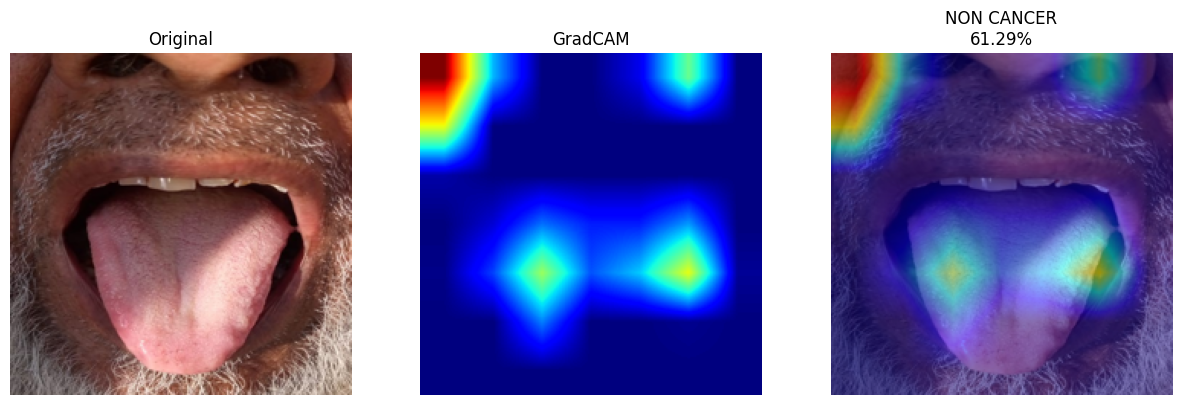

In [15]:
plt.figure(figsize=(15,5))

plt.subplot(131)

plt.imshow(result["image"])

plt.title("Original")

plt.axis("off")

plt.subplot(132)

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.title("GradCAM")

plt.axis("off")

plt.subplot(133)

plt.imshow(overlay)

plt.title(
    f"{result['prediction']}\n"
    f"{result['confidence']*100:.2f}%"
)

plt.axis("off")

plt.show()

In [16]:
confidence = result["confidence"]

if confidence >= 0.90:
    risk = "High Confidence"

elif confidence >= 0.70:
    risk = "Medium Confidence"

else:
    risk = "Low Confidence"

print("Prediction :", result["prediction"])

print("Confidence :", f"{confidence*100:.2f}%")

print("Risk Level :", risk)

Prediction : NON CANCER
Confidence : 61.29%
Risk Level : Low Confidence


In [17]:
print("="*60)

print("MEDICAL DISCLAIMER")

print("="*60)

print(
    """
This AI system is intended only for preliminary
screening and educational purposes.

It DOES NOT diagnose oral cancer.

Any suspicious lesion should always be examined
by a qualified dentist or oral oncologist.

The final diagnosis requires clinical examination,
medical history, and biopsy.
"""
)

MEDICAL DISCLAIMER

This AI system is intended only for preliminary
screening and educational purposes.

It DOES NOT diagnose oral cancer.

Any suspicious lesion should always be examined
by a qualified dentist or oral oncologist.

The final diagnosis requires clinical examination,
medical history, and biopsy.



In [18]:
output_dir = project_root / "results"

output_dir.mkdir(
    exist_ok=True
)

save_path = (
    output_dir /
    f"{Path(image_path).stem}_result.png"
)

Image.fromarray(
    overlay
).save(save_path)

print(save_path)

e:\PROJECTS\OralScan-AI\results\372_result.png
